# Import Libraries

In [ ]:
from glob import glob
from tqdm import tqdm

import pydicom
import SimpleITK as sitk

from dataclasses import fields
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
import sys
sys.path.append('../src')

from pixcell.configs import get_default_config
from pixcell.utils import PathResolver

In [4]:
config = get_default_config()
path = PathResolver(config)

DATA_DIR = config.data_dir
DF_PATH = path.df_path

# Utils

In [4]:
import inspect

from pixcell.data.engine.reconstruction.image import DicomVolumeReader
print(inspect.getsource(DicomVolumeReader.read))

    def read(
        self,
        source: list[Path]
    ) -> VolumeImage:


        reader = sitk.ImageSeriesReader()

        reader.SetFileNames(
            [str(path) for path in source]
        )

        #reader.MetaDataDictionaryArrayUpdateOn()
        #reader.LoadPrivateTagsOn()

        image = reader.Execute()

        ordered_slice_ids = [
            (path.parent.name, path.stem)
            for path in source
        ]

        return VolumeImage(
            image=image,
            ordered_slice_ids=ordered_slice_ids,
        )



In [ ]:
#PathResolver(config).metadata_path().unlink()
path = PathResolver(config).metadata_path()
print(path)
print(path.exists())

#### sitk

In [ ]:
series_dir = Path(r'')
files = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(series_dir)

reader = sitk.ImageSeriesReader()
reader.SetFileNames(files)

image = reader.Execute()
image = sitk.GetArrayFromImage(image)

#-----------------------------------------------

volume = sitk.ReadImage(files, sitk.sitkInt32)
volume_array = np.array(
    sitk.GetArrayFromImage(volume),
    dtype=np.float32,
)

#### pydicom

In [ ]:
dicom_p = "dicom path"
img = pydicom.dcmread()

px = pydicom.dcmread().pixel_array
metadata = pydicom.dcmread(dicom_p, stop_before_pixels=True)

plt.imshow(img.pixel_array,cmap='gray')

# Reconstruction

#### Configuration

In [4]:
from pixcell.configs.data_config import AnnotationConfig

In [5]:

config.data.dataset_subset = "annotated_and_labeled_slices"

# reconstuction
config.data.reconstruction.enabled = False
config.data.reconstruction.cache = True
config.data.reconstruction.load = False

config.data.reconstruction.image.reader = "dicom_volume_reader"

config.data.reconstruction.annotation.targets = [
    AnnotationConfig(
        task="ICH",
        builder="binary_mask_for_class_volume",
        parameters={
            "class_value":1,
        },
        cache_key=1,
    )
]

# resample
config.data.reconstruction.resample.enabled = False

#### Build dataset and metadata

In [ ]:
from pixcell.data.engine.reconstruction.builder import Reconstruction

dataset, metadata = Reconstruction(config).build()

## Dataset Discovery

Alternatively, you can automatically discover the dataset by using:

---
```python
from pixcell.data.dataset_discovery import DatasetDiscovery

dataset = DatasetDiscovery(
    DATA_DIR,
    dicom=True,
    annotation=True,
    dataframe=True,
).discover()
```
---

In [7]:
display(dataset.name)
display(dataset.structure.is_valid)
dataset.summary

'iaaa-contest-bct'

True

DatasetSummary(num_patients=320, num_series=338, num_slices=7683, annotated_series=198, annotated_slices=5176, missing_dicoms=0, missing_annotations=2507, missing_dataframe_rows=175)

#### patients

In [8]:
for patient in dataset.patients.values():
    if len(patient.series_ids) > 1:  
        print(patient)

PatientManifest(patient_id='264685', series_ids=['1032', '1033'])
PatientManifest(patient_id='687671', series_ids=['1938', '1939'])
PatientManifest(patient_id='695481', series_ids=['1996', '1997', '1999'])
PatientManifest(patient_id='700862', series_ids=['2023', '2024'])
PatientManifest(patient_id='711366', series_ids=['2068', '2069'])
PatientManifest(patient_id='767333', series_ids=['2386', '2388'])
PatientManifest(patient_id='767996', series_ids=['2557', '2558'])
PatientManifest(patient_id='1efbad874b5879af7d78c50f3827c0fa1d8eeb5e7fd7cb275f6726eb3230baf5', series_ids=['270909', '271785'])
PatientManifest(patient_id='0869c48f2112d765bd8d56fd90ed4fc10d73dd4a55a34bd9e66a20023c94bc67', series_ids=['272179', '272520'])
PatientManifest(patient_id='768975', series_ids=['2847', '2850'])
PatientManifest(patient_id='769358', series_ids=['2951', '2952', '2953'])
PatientManifest(patient_id='770803', series_ids=['3122', '3125'])
PatientManifest(patient_id='776467', series_ids=['4325', '4326', '43

### Series

In [9]:
mismatch = []
for series in dataset.series.values():
    if not series.num_annotations == 0 and not series.num_dicoms == 0:
        if not series.num_annotations == series.num_dicoms:
            print(f"series_id {series.series_id}, has {series.num_dicoms} dicom files but {series.num_annotations} annotation files.") 
            mismatch.append(series.series_id)

series_id 1952, has 29 dicom files but 21 annotation files.
series_id 2200, has 16 dicom files but 10 annotation files.
series_id 2388, has 16 dicom files but 9 annotation files.
series_id 2722, has 16 dicom files but 13 annotation files.
series_id 2818, has 16 dicom files but 10 annotation files.


In [10]:
dicom_counts_list = [series.num_dicoms for series in dataset.series.values()]
dicom_counts = Counter(dicom_counts_list)
print("Distribution of the number of slices in DICOM data:")
for item in sorted(dicom_counts.items()):
    print(item)

print("Distribution of the number of slices in Annotations data:")
annotation_counts_list = [series.num_annotations for series in dataset.series.values()]
annotation_counts = Counter(annotation_counts_list)
for item in sorted(annotation_counts.items()):
    print(item)


print("dicom_counts:")
display(pd.Series(dicom_counts_list).describe())
print("annotation_counts:")
display(pd.Series(annotation_counts_list).describe())
    

Distribution of the number of slices in DICOM data:
(16, 189)
(20, 5)
(24, 1)
(26, 5)
(27, 4)
(28, 19)
(29, 31)
(30, 9)
(31, 3)
(32, 29)
(33, 4)
(34, 12)
(35, 3)
(36, 11)
(38, 5)
(39, 2)
(40, 3)
(46, 1)
(50, 2)
Distribution of the number of slices in Annotations data:
(0, 140)
(9, 1)
(10, 2)
(13, 1)
(16, 67)
(20, 1)
(21, 1)
(26, 4)
(27, 4)
(28, 14)
(29, 19)
(30, 9)
(31, 3)
(32, 29)
(33, 4)
(34, 12)
(35, 3)
(36, 11)
(38, 5)
(39, 2)
(40, 3)
(46, 1)
(50, 2)
dicom_counts:


count    338.000000
mean      22.730769
std        8.188887
min       16.000000
25%       16.000000
50%       16.000000
75%       29.000000
max       50.000000
dtype: float64

annotation_counts:


count    338.000000
mean      15.313609
std       14.491454
min        0.000000
25%        0.000000
50%       16.000000
75%       29.000000
max       50.000000
dtype: float64

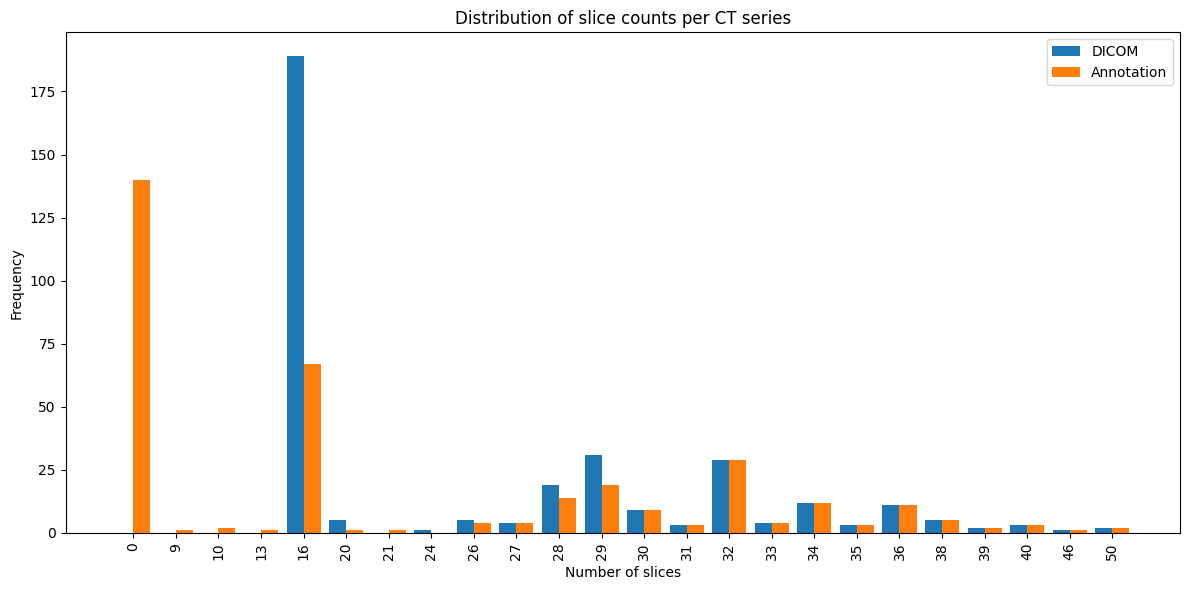

In [11]:
# Union 
x = sorted(set(dicom_counts) | set(annotation_counts))

dicom_y = [dicom_counts.get(i, 0) for i in x]
annotation_y = [annotation_counts.get(i, 0) for i in x]

width = 0.4
indices = np.arange(len(x))

plt.figure(figsize=(12, 6))
plt.bar(indices - width/2, dicom_y, width=width, label="DICOM")
plt.bar(indices + width/2, annotation_y, width=width, label="Annotation")

plt.xticks(indices, x, rotation=90)
plt.xlabel("Number of slices")
plt.ylabel("Frequency")
plt.title("Distribution of slice counts per CT series")
plt.legend()
plt.tight_layout()
plt.show()


### slices

In [12]:
dataset.slices

{('1011',
  '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789'): SliceManifest(series_id='1011', sop_uid='1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789', patient_id='260240', dicom_path=WindowsPath('S:/work/Projects/PixCell/data/training/1011/1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789.dcm'), annotation_path=WindowsPath('S:/work/Projects/PixCell/data/annotations/1011/1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789.json'), dataframe_index=3438, has_dicom=True, has_annotation=True, has_dataframe=True),
 ('1011',
  '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.921923'): SliceManifest(series_id='1011', sop_uid='1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.921923', patient_id='260240', dicom_path=WindowsPath('S:/work/Projects/PixCell/data/training/1011/1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.921923.dcm'), annotation_path=WindowsPath('S:/work/Projects/PixCell/data/annotations/1011/1.2.392.200036.9116.2.6.1.3268

## Metadata

Alternatively, you can automatically extract metadata and labels by using:

---
```python
from pixcell.data.metadata import Metadata

metadata = Metadata(config).build(dataset)
```
---

In [13]:
metadata.series

{'1011': SeriesMetadata(patient_id='260240', series_id='1011', ordered_slice_keys=[('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.921923'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217416.795493'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217417.455308'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217418.262080'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217419.102643'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217419.906690'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217420.712166'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217421.521639'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217422.391352'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217423.184580'), ('1011', '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217423.993451'), ('1011', '1.2.392.200036.9116.2.6.1.3268.

In [14]:
metadata.slices

{('1011',
  '1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789'): SliceMetadata(patient_id='260240', series_id='1011', sop_uid='1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789', dicom_path=WindowsPath('S:/work/Projects/PixCell/data/training/1011/1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789.dcm'), annotation_path=WindowsPath('S:/work/Projects/PixCell/data/annotations/1011/1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789.json'), dicom=DicomMetadata(patient_id='260240', frame_of_reference_uid='1.2.392.200036.9116.2.6.1.3268.2054351322.1641217321.837511', rows=512, columns=512, pixel_spacing=(0.449, 0.449), slice_thickness=5.0, image_orientation_patient=(1.0, 0.0, 0.0, 0.0, 0.96593, -0.25882), image_position_patient=(-114.775, -94.56451, -524.1615), slice_location=0.0, instance_number=1, rescale_intercept=0.0, rescale_slope=1.0, window_center=40.0, window_width=120.0, bits_allocated=16, bits_stored=16, pixel_representation=1, samples_per_pixe

### Dicom

In [15]:
sample = [s.dicom_path for s in dataset.slices.values()][0]
ds = pydicom.dcmread(str(sample), stop_before_pixels=True)

elem = ds[(0x0008, 0x0060)]
print(elem.tag)
print(elem.name)
print(elem.VR)
print(elem.value)

ds

(0008,0060)
Modality
CS
CT


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 226
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMBP_360'
(0002,0016) Source Application Entity Title     AE: 'TM_CT_CMW_V3.00'
-------------------------------------------------
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789
(0008,0020) Study Date             

In [16]:
l = []

for s in metadata.slices.values():
    c = getattr(s.dicom, "rescale_intercept")
    if c < 0:
        l.append(s.series_id)

len(set(l))

84

In [17]:
def dicom_nunique(tag: str):

    unique = {
        getattr(s.dicom, tag)
        for s in metadata.slices.values()
        if getattr(s.dicom, tag) is not None
    }

    return f"DICOM '{tag}' has {len(unique)} unique value(s): {sorted(unique)}"


first_slice = next(iter(metadata.slices.values()))

for field in fields(first_slice.dicom):
    print(dicom_nunique(field.name))

DICOM 'patient_id' has 320 unique value(s): ['127716', '129026', '144567', '14615', '157781', '158377', '16579896', '17095', '177019', '192895', '193532', '197290', '197326', '198715', '2012', '205139', '216644', '222122', '223151', '223267', '231909', '233700', '236066', '2380', '238025', '238419', '239067', '254978', '256449', '257283', '257501', '260240', '26393', '264685', '270141', '274039', '274157', '278025', '330957', '3529', '35318', '367501', '374739', '3808', '48503', '48800352', '49615', '510583', '515942', '528955', '54412', '546206', '565730', '597149', '639805', '649125', '653225', '685943', '686247', '687436', '687671', '689602', '690564', '692360', '692718', '692845', '695481', '700862', '702023', '705206', '71085', '711366', '724281', '735841', '755624', '760495', '765202', '766734', '766821', '766930', '767131', '767281', '767323', '767333', '767418', '767432', '767470', '767504', '767612', '767834', '767838', '767994', '767996', '768066', '768083', '768104', '768204

### Annotation

In [18]:
annotations = [
    s.annotation
    for s in metadata.slices.values()
    if s.annotation is not None
]

has_segmentation = sum(a.has_segmentation for a in annotations)

has_keypoints = sum(a.has_keypoints for a in annotations)

has_boxes = sum(a.has_boxes for a in annotations)

segmentation_shapes = {
    a.segmentation_shape
    for a in annotations
}

num_segmentation_classes = {
    a.num_segmentation_classes
    for a in annotations
}

class_map = {
    a.class_map
    for a in annotations
}

num_boxes = {
    a.num_boxes
    for a in annotations
}

box_distribution = Counter(
    a.num_boxes
    for a in annotations
)

print(f"Annotated slices            : {len(annotations)}")
print(f"Slices with segmentation   : {has_segmentation}")
print(f"Slices with keypoints      : {has_keypoints}")
print(f"Slices with bounding boxes : {has_boxes}")
print(f"Segmentation shapes        : {sorted(segmentation_shapes)}")
print(f"Segmentation classes       : {sorted(num_segmentation_classes)}")
print(f"Class maps                 : {sorted(class_map)}")
print(f"Bounding box counts        : {sorted(num_boxes)}")
print(f"Bounding box distribution  : {box_distribution}")

Annotated slices            : 5176
Slices with segmentation   : 5176
Slices with keypoints      : 5176
Slices with bounding boxes : 5176
Segmentation shapes        : [(512, 512)]
Segmentation classes       : [6]
Class maps                 : [(('BG', 0), ('IntraventricularHemorrhage', 1), ('IntraparenchymalHemorrhage', 2), ('SubduralHemorrhage', 3), ('EpiduralHemorrhage', 4), ('SubarachnoidHemorrhage', 5))]
Bounding box counts        : [0, 1, 2, 3, 4]
Bounding box distribution  : Counter({0: 4916, 1: 177, 2: 72, 3: 9, 4: 2})


### Dataframe

In [23]:
from eda_helpers import(
    all_data_class_distribution,
    ICHOverlapAnalyzer
)

In [5]:
df = pd.read_pickle(DF_PATH)
df.head()

,dicom_series.id,dicom_series.NumDicomFiles,dicom_series.PatientID,dicom_series.StudyInstanceUID,dicom_series.SeriesInstanceUID,dicom_series.SOPInstanceUID,dicom_series.PixelSpacing0,dicom_series.PixelSpacing1,dicom_series.SliceThickness,IntraventricularHemorrhage,IntraparenchymalHemorrhage,SubarachnoidHemorrhage,EpiduralHemorrhage,SubduralHemorrhage,IntraventricularHemorrhage_Area,IntraparenchymalHemorrhage_Area,SubarachnoidHemorrhage_Area,EpiduralHemorrhage_Area,SubduralHemorrhage_Area,SkullFracture,MidlineShiftMM,RelativeAnnotationPath,AnyICH,triage_class
0,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_beba6a8e7,0.488281,0.488281,5.06,False,False,False,False,False,0,0,0,0,0,False,0.1,271208/ID_beba6a8e7.json,False,2
1,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_e482af39d,0.488281,0.488281,5.06,False,False,False,False,False,0,0,0,0,0,False,0.1,271208/ID_e482af39d.json,False,2
2,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_4f4c7acd0,0.488281,0.488281,5.06,False,False,False,False,False,0,0,0,0,0,False,0.1,271208/ID_4f4c7acd0.json,False,2
3,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_a39f8e984,0.488281,0.488281,5.06,False,True,False,False,False,0,895,0,0,0,False,0.1,271208/ID_a39f8e984.json,True,2
4,271208,36,d103224800bddd812d6d4cc454211dd70fee8ddd801516...,ID_4e0c9c656c,ID2b1125f213,ID_36d6d9505,0.488281,0.488281,5.06,False,True,False,False,False,0,1575,0,0,0,False,0.1,271208/ID_36d6d9505.json,True,2


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 7508 entries, 0 to 175991
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   dicom_series.id                  7508 non-null   int64  
 1   dicom_series.NumDicomFiles       7508 non-null   int64  
 2   dicom_series.PatientID           7508 non-null   object 
 3   dicom_series.StudyInstanceUID    7508 non-null   object 
 4   dicom_series.SeriesInstanceUID   7508 non-null   object 
 5   dicom_series.SOPInstanceUID      7508 non-null   object 
 6   dicom_series.PixelSpacing0       7508 non-null   float64
 7   dicom_series.PixelSpacing1       7508 non-null   float64
 8   dicom_series.SliceThickness      7508 non-null   object 
 9   IntraventricularHemorrhage       7508 non-null   bool   
 10  IntraparenchymalHemorrhage       7508 non-null   bool   
 11  SubarachnoidHemorrhage           7508 non-null   bool   
 12  EpiduralHemorrhage               7

In [26]:
df.select_dtypes(include=[np.number]).describe().T

,count,mean,std,min,25%,50%,75%,max
dicom_series.id,7508.0,100514.291023,130364.780063,447.0,2034.0,6665.0,271335.0,342691.0
dicom_series.NumDicomFiles,7508.0,25.807006,8.674289,16.0,16.0,28.0,32.0,50.0
dicom_series.PixelSpacing0,7508.0,0.477113,0.030078,0.398438,0.468,0.468,0.488281,0.625
dicom_series.PixelSpacing1,7508.0,0.477113,0.030078,0.398438,0.468,0.468,0.488281,0.625
IntraventricularHemorrhage_Area,7508.0,96.930741,591.706251,0.0,0.0,0.0,0.0,11401.0
IntraparenchymalHemorrhage_Area,7508.0,539.19073,1976.111367,0.0,0.0,0.0,0.0,21944.0
SubarachnoidHemorrhage_Area,7508.0,38.692195,341.749456,0.0,0.0,0.0,0.0,10636.0
EpiduralHemorrhage_Area,7508.0,63.10935,551.216256,0.0,0.0,0.0,0.0,10398.0
SubduralHemorrhage_Area,7508.0,228.329382,1361.910894,0.0,0.0,0.0,0.0,26646.0
MidlineShiftMM,7508.0,1.303488,3.428087,0.0,0.1,0.1,0.1,103.347054


In [27]:
df.isnull().sum().sort_values(ascending=False)

dicom_series.id                    0
dicom_series.NumDicomFiles         0
dicom_series.PatientID             0
dicom_series.StudyInstanceUID      0
dicom_series.SeriesInstanceUID     0
dicom_series.SOPInstanceUID        0
dicom_series.PixelSpacing0         0
dicom_series.PixelSpacing1         0
dicom_series.SliceThickness        0
IntraventricularHemorrhage         0
IntraparenchymalHemorrhage         0
SubarachnoidHemorrhage             0
EpiduralHemorrhage                 0
SubduralHemorrhage                 0
IntraventricularHemorrhage_Area    0
IntraparenchymalHemorrhage_Area    0
SubarachnoidHemorrhage_Area        0
EpiduralHemorrhage_Area            0
SubduralHemorrhage_Area            0
SkullFracture                      0
MidlineShiftMM                     0
RelativeAnnotationPath             0
AnyICH                             0
triage_class                       0
dtype: int64

In [30]:
df["ann_test"] = df.apply(
    lambda row: path.slice_path(
        str(row["dicom_series.id"]),
        str(row["dicom_series.SOPInstanceUID"])
    ),
    axis=1
)

sum(df.RelativeAnnotationPath == df.ann_test)

0

#### Labels

In [31]:
metadata.slices[('1011','1.2.392.200036.9116.2.6.1.3268.2054351322.1641217415.116789')].labels

LabelMetadata(any_ich=0, IVH=0, IPH=0, SAH=0, EDH=0, SDH=0, IVH_area=0.0, IPH_area=0.0, SAH_area=0.0, EDH_area=0.0, SDH_area=0.0, skull_fracture=0, midline_shift_mm=0.1, triage_class=2, keypoints={'AnteriorFalxAttachment': Keypoint(x=None, y=None), 'PosteriorFalxAttachment': Keypoint(x=None, y=None), 'OutermostPointOfTheFalx': Keypoint(x=None, y=None)}, bounding_boxes=[])

##### Skull Fracture

In [32]:
all_data_class_distribution(df, "SkullFracture")


Class Distribution for 'SkullFracture'

Slice-wise Distribution
------------------------------------------------------------
Class False:     7248 ( 96.54%)
Class True:      260 (  3.46%)

Series-wise Distribution
------------------------------------------------------------
Class False:      310 ( 91.72%)
Class True:       28 (  8.28%)


##### Midline Shift

In [33]:
df.MidlineShiftMM.describe()

count        7508.0
mean       1.303488
std        3.428087
min             0.0
25%             0.1
50%             0.1
75%             0.1
max      103.347054
Name: MidlineShiftMM, dtype: Float64

In [34]:
lower = 0.1
upper = 1
msh_dist = {}

for i in range(104):
    cnt = df[(df.MidlineShiftMM > lower) & (df.MidlineShiftMM <upper)].count()['MidlineShiftMM']
    print(f"range {lower}:{upper} = {cnt}")
    msh_dist[str(f"{lower}:{upper}")] = cnt
    lower = upper
    upper = lower + 1

range 0.1:1 = 305
range 1:2 = 290
range 2:3 = 209
range 3:4 = 141
range 4:5 = 132
range 5:6 = 96
range 6:7 = 80
range 7:8 = 75
range 8:9 = 54
range 9:10 = 46
range 10:11 = 60
range 11:12 = 56
range 12:13 = 35
range 13:14 = 27
range 14:15 = 33
range 15:16 = 14
range 16:17 = 18
range 17:18 = 18
range 18:19 = 22
range 19:20 = 14
range 20:21 = 10
range 21:22 = 2
range 22:23 = 4
range 23:24 = 1
range 24:25 = 0
range 25:26 = 0
range 26:27 = 0
range 27:28 = 0
range 28:29 = 0
range 29:30 = 0
range 30:31 = 0
range 31:32 = 0
range 32:33 = 0
range 33:34 = 0
range 34:35 = 0
range 35:36 = 0
range 36:37 = 0
range 37:38 = 0
range 38:39 = 0
range 39:40 = 0
range 40:41 = 0
range 41:42 = 0
range 42:43 = 0
range 43:44 = 0
range 44:45 = 0
range 45:46 = 0
range 46:47 = 0
range 47:48 = 0
range 48:49 = 0
range 49:50 = 0
range 50:51 = 0
range 51:52 = 0
range 52:53 = 0
range 53:54 = 0
range 54:55 = 0
range 55:56 = 0
range 56:57 = 0
range 57:58 = 0
range 58:59 = 0
range 59:60 = 0
range 60:61 = 0
range 61:62 = 0

In [35]:
df[df.MidlineShiftMM>100]["dicom_series.id"]

2715    271528
Name: dicom_series.id, dtype: int64

<Axes: ylabel='Count'>

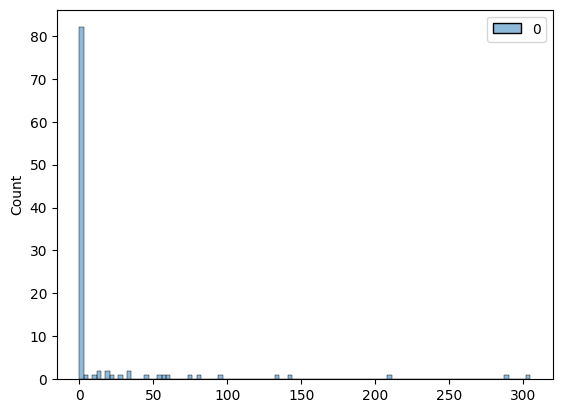

In [36]:
sns.histplot(msh_dist.values(),bins=104, kde=False, color='purple')

##### ICH

In [6]:
ich_map = {
    'IntraventricularHemorrhage_Area': 'V_IVH',
    'IntraparenchymalHemorrhage_Area': 'V_IPH',
    'SubarachnoidHemorrhage_Area': 'V_SAH',
    'EpiduralHemorrhage_Area': 'V_EDH',
    'SubduralHemorrhage_Area': 'V_SDH',

    'IntraventricularHemorrhage': 'IVH',
    'IntraparenchymalHemorrhage': 'IPH',
    'SubarachnoidHemorrhage': 'SAH',
    'EpiduralHemorrhage': 'EDH',
    'SubduralHemorrhage': 'SDH',
}

df = df.rename(columns=ich_map)

In [7]:
ich_types = ['IVH','IPH','SAH','EDH','SDH']
ich_area = ['V_IVH', 'V_IPH', 'V_SAH', 'V_EDH', 'V_SDH']

In [10]:
df[ich_area].describe()

,V_IVH,V_IPH,V_SAH,V_EDH,V_SDH
count,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000
mean,96.930741,539.190730,38.692195,63.109350,228.329382
std,591.706251,1976.111367,341.749456,551.216256,1361.910894
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,11401.000000,21944.000000,10636.000000,10398.000000,26646.000000


series level:
| Class | Series |
| ----- | ------ |
| IPH   | 33%    |
| IVH   | 16%    |
| SDH   | 13%    |
| SAH   | 7%     |
| EDH   | 5%     |

slice level:
| Class | Slice |
| ----- | ----- |
| IPH   | 12.6% |
| SDH   | 5.8%  |
| IVH   | 5.5%  |
| SAH   | 2.6%  |
| EDH   | 2%    |


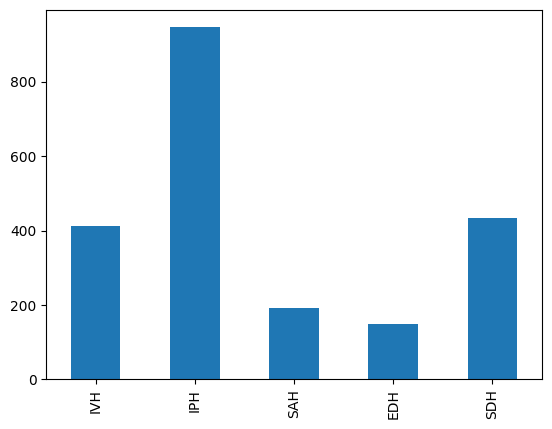

In [39]:
df[ich_types].sum().plot(kind="bar")
plt.show()

In [40]:
all_data_class_distribution(df, "AnyICH")


Class Distribution for 'AnyICH'

Slice-wise Distribution
------------------------------------------------------------
Class False:     5975 ( 79.58%)
Class True:     1533 ( 20.42%)

Series-wise Distribution
------------------------------------------------------------
Class False:      184 ( 54.44%)
Class True:      154 ( 45.56%)


In [41]:
all_data_class_distribution(df, "IVH")


Class Distribution for 'IVH'

Slice-wise Distribution
------------------------------------------------------------
Class False:     7095 ( 94.50%)
Class True:      413 (  5.50%)

Series-wise Distribution
------------------------------------------------------------
Class False:      285 ( 84.32%)
Class True:       53 ( 15.68%)


In [42]:
all_data_class_distribution(df, "IPH")


Class Distribution for 'IPH'

Slice-wise Distribution
------------------------------------------------------------
Class False:     6562 ( 87.40%)
Class True:      946 ( 12.60%)

Series-wise Distribution
------------------------------------------------------------
Class False:      225 ( 66.57%)
Class True:      113 ( 33.43%)


In [43]:
all_data_class_distribution(df, "SAH")


Class Distribution for 'SAH'

Slice-wise Distribution
------------------------------------------------------------
Class False:     7315 ( 97.43%)
Class True:      193 (  2.57%)

Series-wise Distribution
------------------------------------------------------------
Class False:      315 ( 93.20%)
Class True:       23 (  6.80%)


In [44]:
all_data_class_distribution(df, "EDH")


Class Distribution for 'EDH'

Slice-wise Distribution
------------------------------------------------------------
Class False:     7358 ( 98.00%)
Class True:      150 (  2.00%)

Series-wise Distribution
------------------------------------------------------------
Class False:      322 ( 95.27%)
Class True:       16 (  4.73%)


In [45]:
all_data_class_distribution(df, "SDH")


Class Distribution for 'SDH'

Slice-wise Distribution
------------------------------------------------------------
Class False:     7074 ( 94.22%)
Class True:      434 (  5.78%)

Series-wise Distribution
------------------------------------------------------------
Class False:      294 ( 86.98%)
Class True:       44 ( 13.02%)


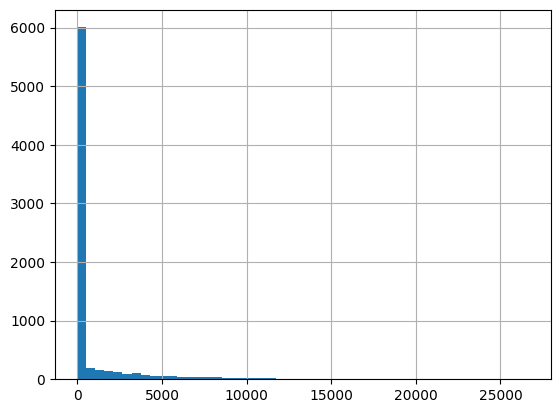

count     7508.000000
mean       966.252397
std       2694.033478
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      26646.000000
Name: TotalHemorrhageArea, dtype: float64


In [46]:
area_cols = [
    "V_IVH",
    "V_IPH",
    "V_SAH",
    "V_EDH",
    "V_SDH"
]

df["TotalHemorrhageArea"] = df[area_cols].sum(axis=1)

df["TotalHemorrhageArea"].hist(bins=50)
plt.show()

print(df["TotalHemorrhageArea"].describe())

This indicates that the majority of patients have no detectable hemorrhage, while a small subset presents with very large hemorrhagic regions.

The strong skewness and presence of extreme outliers suggest that transformations (e.g., log scaling) may be required for regression modeling. Additionally, this variable may strongly correlate with clinical severity indicators such as midline shift.

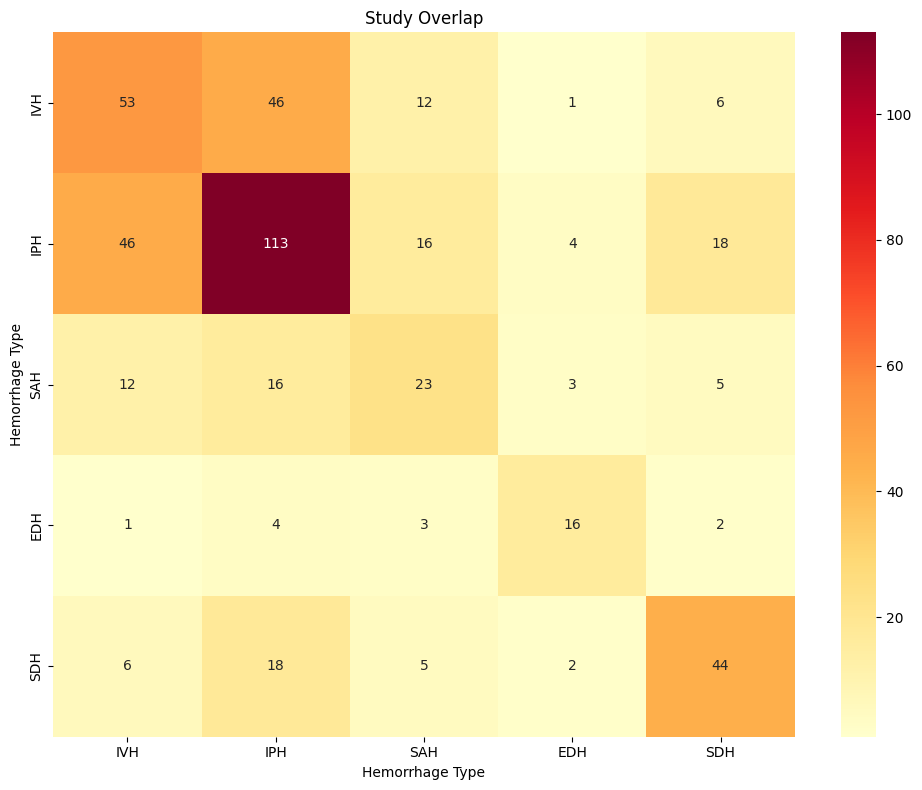

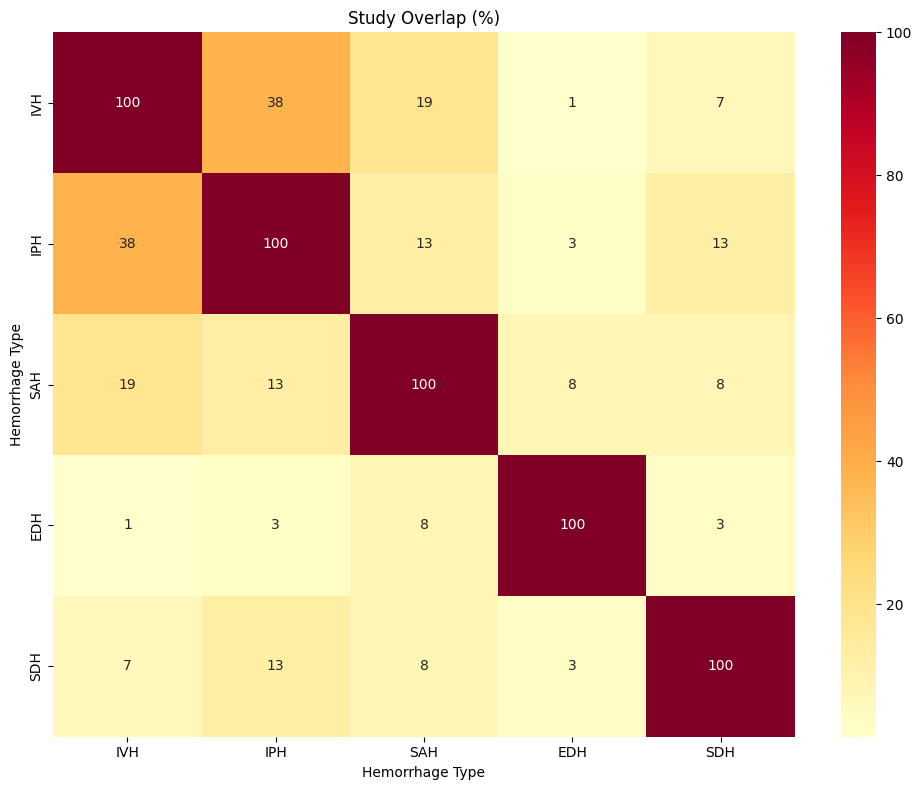

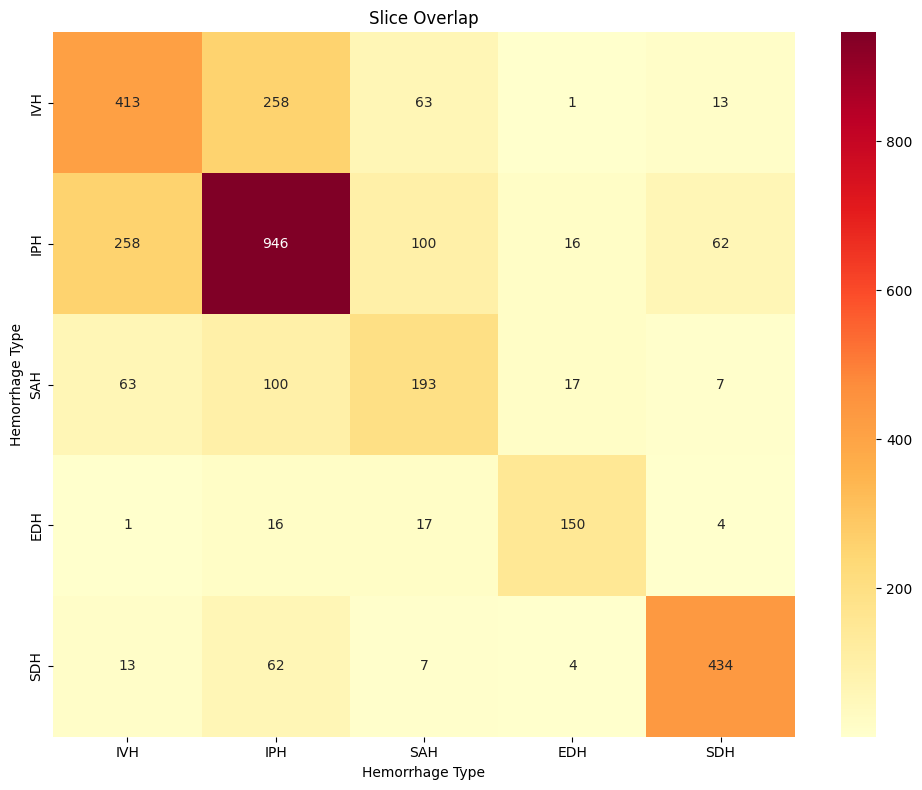

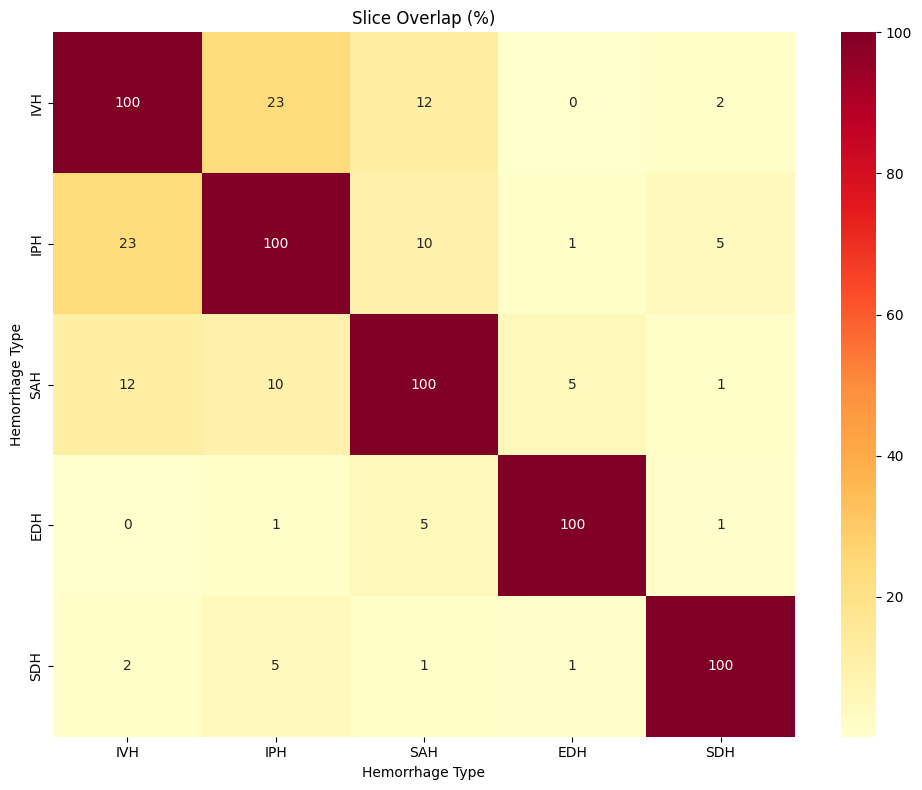

In [47]:
analyzer = ICHOverlapAnalyzer(df, ich_types)
analyzer.compute()
analyzer.plot_all()

##### ICH & MLS

In [48]:
hemorrhage = set(df[df.AnyICH == True]["dicom_series.id"]) 
mls = set(df[df.MidlineShiftMM > 0.1]["dicom_series.id"]) 

intersection = hemorrhage.intersection(mls)

pct_mls_with_ich = len(intersection) / len(mls)
pct_ich_with_mls = len(intersection) / len(hemorrhage)

print(f"Total series with ICH: {len(hemorrhage)}")
print(f"Total series with Midline Shift (>0.1 mm): {len(mls)}")
print(f"Series with both ICH and Midline Shift: {len(intersection)}")
print()
print(f"{pct_mls_with_ich:.2%} of series with Midline Shift also have ICH.")
print(f"{pct_ich_with_mls:.2%} of series with ICH also have Midline Shift.")

Total series with ICH: 154
Total series with Midline Shift (>0.1 mm): 177
Series with both ICH and Midline Shift: 154

87.01% of series with Midline Shift also have ICH.
100.00% of series with ICH also have Midline Shift.


In [49]:
for type in df[ich_types]:
    hemmorhage = set(df[df[type] == True]["dicom_series.id"])
    intersection = hemmorhage.intersection(mls)

    percent = np.round(len(intersection) / len(mls),2)
    print(
        f"  - {type}: {len(intersection):3d} series "
        f"({percent:.2%}) also have {type}."
    )

  - IVH:  53 series (30.00%) also have IVH.
  - IPH: 113 series (64.00%) also have IPH.
  - SAH:  23 series (13.00%) also have SAH.
  - EDH:  16 series (9.00%) also have EDH.
  - SDH:  44 series (25.00%) also have SDH.


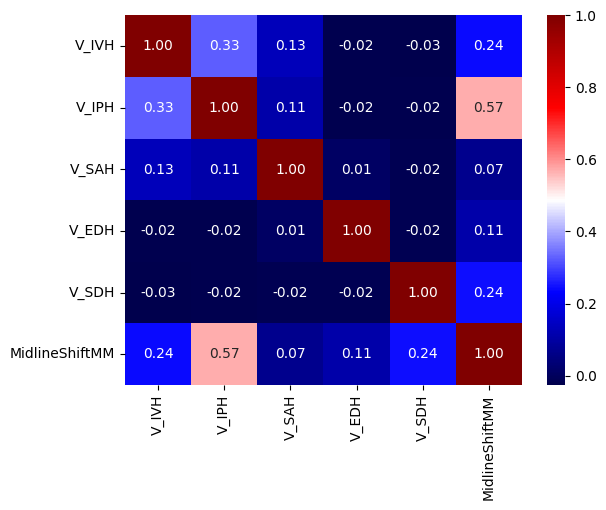

In [51]:
corr = df[ich_area + ["MidlineShiftMM"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='seismic')
plt.show()

In [52]:
df.groupby("AnyICH")["MidlineShiftMM"].mean()

AnyICH
False    0.438641
True     4.674305
Name: MidlineShiftMM, dtype: Float64

Patients with intracranial hemorrhage exhibit nearly a 10-fold increase in average midline shift compared to patients without hemorrhage.
This finding supports a strong association between hemorrhage presence and brain structure displacement

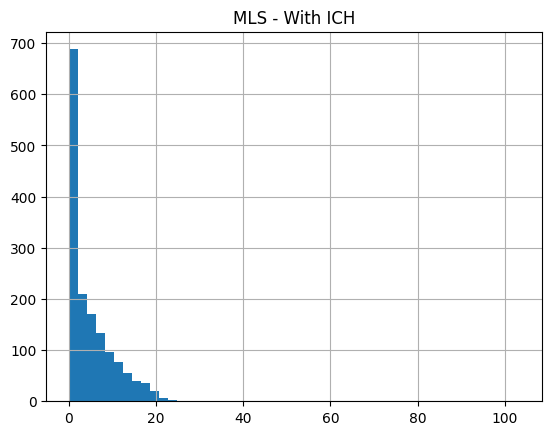

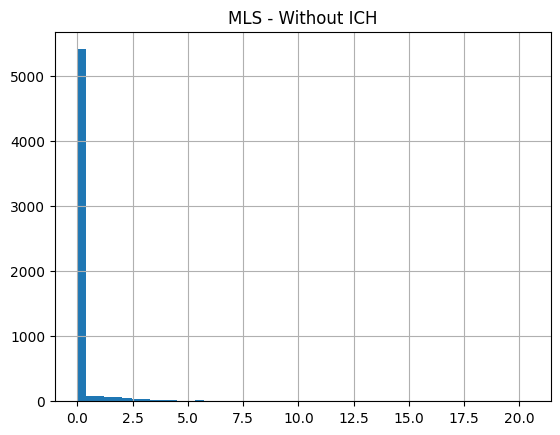

In [53]:
df[df["AnyICH"] == 1]["MidlineShiftMM"].hist(bins=50)
plt.title("MLS - With ICH")
plt.show()

df[df["AnyICH"] == 0]["MidlineShiftMM"].hist(bins=50)
plt.title("MLS - Without ICH")
plt.show()

In [54]:
df["TotalHemorrhageArea"] = df[ich_area].sum(axis=1)

df[["MidlineShiftMM", "TotalHemorrhageArea"]].corr()

,MidlineShiftMM,TotalHemorrhageArea
MidlineShiftMM,1.000000,0.625228
TotalHemorrhageArea,0.625228,1.000000


This indicates a moderately strong positive relationship. Larger hemorrhage areas are associated with greater midline displacement, which is consistent with clinical expectations.

However, the correlation is not perfect, suggesting that additional factors such as hemorrhage location and type may influence the degree of midline shift.

Given the skewed distributions of both variables, further analysis using rank-based correlation methods (e.g., Spearman) may provide additional insight.

In [55]:
mls_positive = df[df["MidlineShiftMM"] > 0.1]
percentage = (mls_positive["AnyICH"].sum() / len(mls_positive)) * 100

percentage

np.float64(63.16695352839932)

##### Triage

In [56]:
all_data_class_distribution(df, 'triage_class', binary=False)


Class Distribution for 'triage_class'

Slice-wise Distribution
------------------------------------------------------------
Class 0:     2832 ( 37.72%)
Class 1:     1461 ( 19.46%)
Class 2:     3215 ( 42.82%)

Series-wise Distribution
------------------------------------------------------------
Class 0:      165 ( 48.82%)
Class 1:       60 ( 17.75%)
Class 2:      113 ( 33.43%)


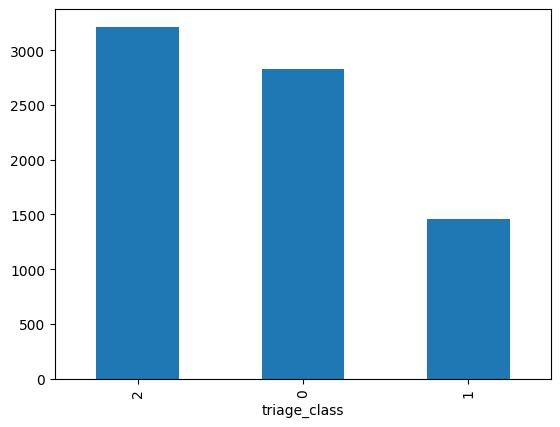

In [57]:
df["triage_class"].value_counts().plot(kind="bar")
plt.show()

# Windowing

In [68]:
from pixcell.data.engine.transforms import Windowing

sample = Path(r"S:\work\Projects\PixCell\processed_data\all_slices\image\volume\3608.npy")
sample = np.load(sample)

sample_w = Windowing.apply_np(sample, window_center=40, window_width=80)

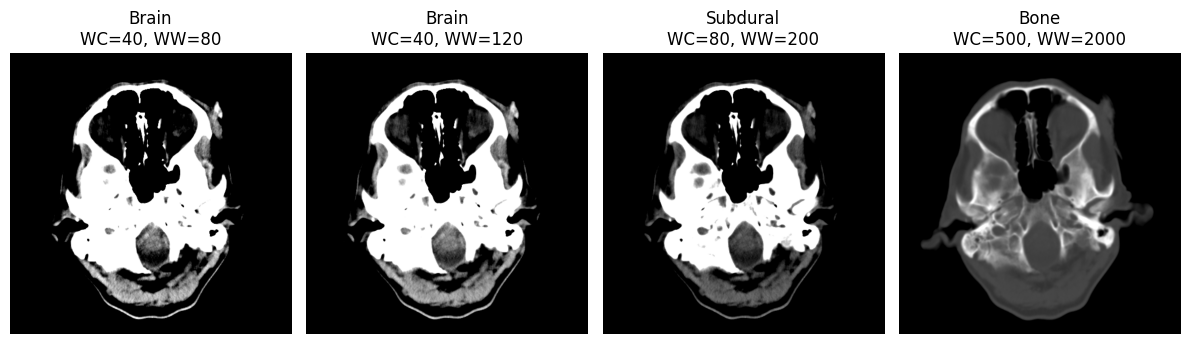

In [69]:
windows = [
    ("Brain", 40, 80),
    ("Brain", 40, 120),
    ("Subdural", 80, 200),
    ("Bone", 500, 2000),
    #("Soft Tissue", 40, 400),
    #("Lung", -600, 1500),
]

fig, axes = plt.subplots(1, len(windows), figsize=(12, 4))

for ax, (title, wc, ww) in zip(axes, windows):
    img = Windowing.apply_np(
        sample[0],
        window_center=wc,
        window_width=ww,
        normalize=True,
    )

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{title}\nWC={wc}, WW={ww}")
    ax.axis("off")

plt.tight_layout()
plt.show()

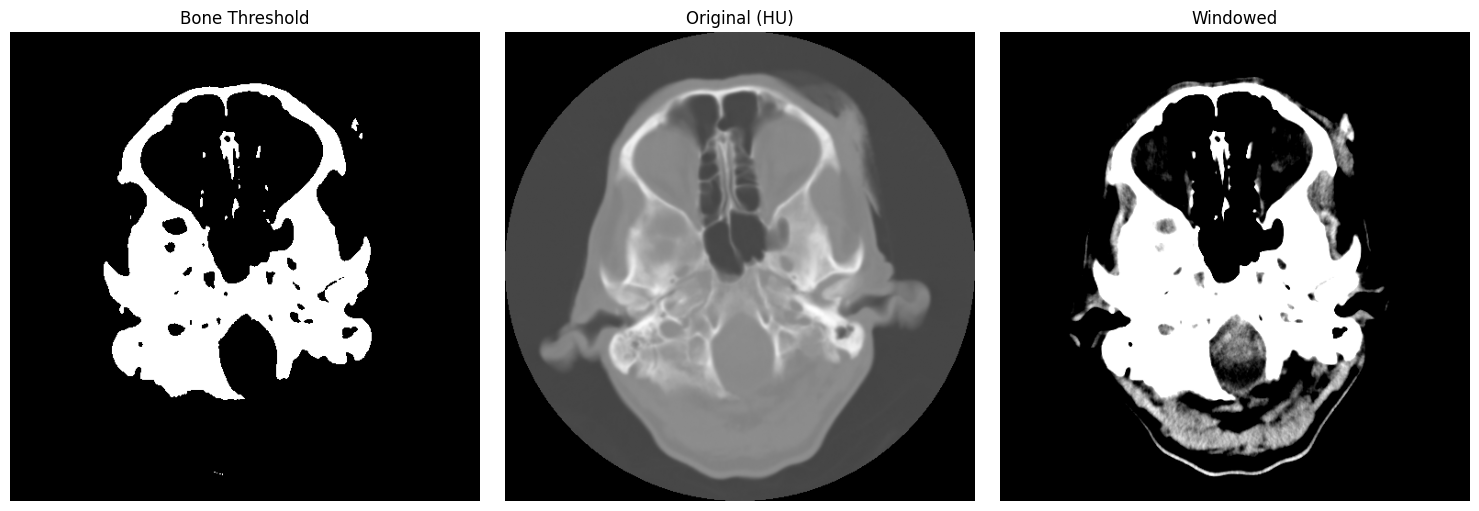

In [70]:
idx = 0  

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(sample[idx] > 80, cmap="gray")
ax[0].set_title("Bone Threshold")

ax[1].imshow(sample[idx], cmap="gray")
ax[1].set_title("Original (HU)")

ax[2].imshow(sample_w[idx], cmap="gray")
ax[2].set_title("Windowed")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

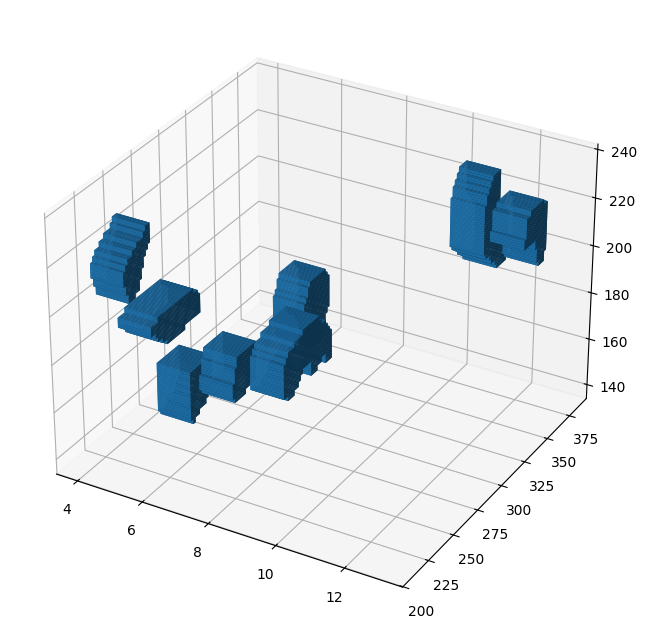

In [74]:
from mpl_toolkits.mplot3d import Axes3D

ann = Path(r"S:\work\Projects\PixCell\processed_data\all_slices\annotation\ICH\binary_masks_by_class_volume\3608-2.npy")
ann = np.load(ann)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.voxels(ann > 0)

plt.show()

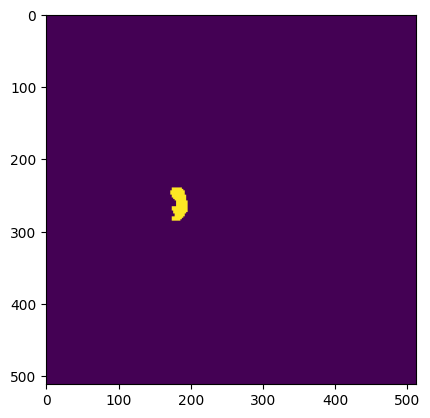

In [75]:
plt.imshow(ann[8])

# Post Process

## MLS 

The issue of midline shift involves two levels:

### 1. Model Level:
The model can approach the problem in two ways:
- **a. MLS Value Regression**: Directly predicting the continuous value of midline shift (MLS).
- **b. Key Point Detection**: Training the model solely to learn the detection of anatomically significant points.

### 2. Clinical Computation Level:
**Step 1**:  
Inputs are derived from the outputs at Level 1.  
If the inputs at Level 2 are keypoints, these points must be transformed into MLS values using a geometric method.

**Step 2**:  
If the model has been optimized for slice-wise processing, all slices of a series should be mapped to a series using an appropriate method.

### Aspects Covered in This Analysis:
- Comparison of geometric methods and their results for converting keypoints to MLS values.
- Examination of methods for assigning MLS values of slices to a series.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [ ]:
ANNOTATION_DIR = Path(r"S:\work\Projects\PixCell\data\annotations")
df = pd.read_pickle(r"S:\work\Projects\PixCell\data\training_df.pkl")

In [ ]:
ann_path = df["RelativeAnnotationPath"].values

points = [
    "AnteriorFalxAttachment",
    "PosteriorFalxAttachment",
    "OutermostPointOfTheFalx"
]

keypoints_dict = {f"{p}_{c}": [] for p in points for c in ["x", "y"]}
keypoints_dict["RelativeAnnotationPath"] = []

for ann in ann_path:
    path = ANNOTATION_DIR / ann
    if path.exists():

        with open(path, "r", encoding="utf-8") as file:
            annotation = json.load(file)

        keypoints = annotation.get("keypoints", {})
        

        for p in points:
            val = keypoints.get(p)

            if val is None:
                keypoints_dict[f"{p}_x"].append(None)
                keypoints_dict[f"{p}_y"].append(None)
                
            else:
                keypoints_dict[f"{p}_x"].append(val[0])
                keypoints_dict[f"{p}_y"].append(val[1])
        keypoints_dict["RelativeAnnotationPath"].append(ann)
    else:
        for p in points:
            keypoints_dict[f"{p}_x"].append("N")
            keypoints_dict[f"{p}_y"].append("N")
        keypoints_dict["RelativeAnnotationPath"].append(ann)

df_kp = pd.DataFrame(keypoints_dict)
df_kp

In [ ]:
df = df.merge(df_kp, on="RelativeAnnotationPath", how="left")
df


In [ ]:
without_kp = df["AnteriorFalxAttachment_x"].isnull().sum()
without_json = (df["AnteriorFalxAttachment_x"] == "N").sum()

print(f"{without_kp} rows have no keypoints")
print(f"{without_json} rows have no JSON file")

In [ ]:
keypoints = [
    'AnteriorFalxAttachment_x',
    'AnteriorFalxAttachment_y',
    'PosteriorFalxAttachment_x', 
    'PosteriorFalxAttachment_y',
    'OutermostPointOfTheFalx_x', 
    'OutermostPointOfTheFalx_y'
]

mask = (df[keypoints] != "N") & (df[keypoints].notna())
df_hkp = df[mask.any(axis=1)]
df_hkp[keypoints] = df_hkp[keypoints].astype(np.float32)

In [ ]:
# df[keypoints] = df[keypoints].replace("N", np.nan)

In [ ]:
df_hkp[keypoints].info()

In [ ]:
df_hkp[keypoints].describe()

### level2.step1

In [ ]:
df_hkp[keypoints + ["MidlineShiftMM"]].corr()["MidlineShiftMM"]

In [ ]:
# Coordinates of the anterior falx attachment (first point defining the midline)
A_x = "AnteriorFalxAttachment_x"
A_y = "AnteriorFalxAttachment_y"

# Coordinates of the posterior falx attachment (second point defining the midline)
P_x = "PosteriorFalxAttachment_x"
P_y = "PosteriorFalxAttachment_y"

# Coordinates of the displaced point (outermost point of the falx)
O_x = "OutermostPointOfTheFalx_x"
O_y = "OutermostPointOfTheFalx_y"

# Compute the midpoint of the falx line
df_hkp["FalxMid_x"] = (df_hkp[A_x] + df_hkp[P_x]) / 2
df_hkp["FalxMid_y"] = (df_hkp[A_y] + df_hkp[P_y]) / 2

# Compute the length of the falx line
df_hkp["FalxLength"] = np.sqrt(
    (df_hkp[P_x] - df_hkp[A_x])**2 +
    (df_hkp[P_y] - df_hkp[A_y])**2
)

# Difference in x and y coordinates between posterior and anterior falx points
df_hkp["Falx_dx"] = df_hkp[P_x] - df_hkp[A_x]
df_hkp["Falx_dy"] = df_hkp[P_y] - df_hkp[A_y]

# Distance from the outermost point to the falx midpoint
df_hkp["Outer_to_Mid"] = np.sqrt(
    (df_hkp[O_x] - df_hkp["FalxMid_x"])**2 +
    (df_hkp[O_y] - df_hkp["FalxMid_y"])**2
)

# Compute the perpendicular distance from the outermost point to the falx line
num = abs(
    (df_hkp[P_y] - df_hkp[A_y]) * df_hkp[O_x] -
    (df_hkp[P_x] - df_hkp[A_x]) * df_hkp[O_y] +
    df_hkp[P_x]*df_hkp[A_y] -
    df_hkp[P_y]*df_hkp[A_x]
)

den = np.sqrt(
    (df_hkp[P_y] - df_hkp[A_y])**2 +
    (df_hkp[P_x] - df_hkp[A_x])**2
)

df_hkp["Outer_to_FalxLine"] = num / den

# List of the new geometric features
features = [
    "FalxMid_x",
    "FalxMid_y",
    "FalxLength",
    "Falx_dx",
    "Falx_dy",
    "Outer_to_Mid",
    "Outer_to_FalxLine"
]

# Compute correlation of these features with the Midline Shift value
corr = df_hkp[features + ["MidlineShiftMM"]].corr()["MidlineShiftMM"].drop("MidlineShiftMM")

print(corr.sort_values(ascending=False))


### Conclusion

The geometric feature **Outer_to_FalxLine** shows an extremely high correlation (≈ 0.997) with the Midline Shift value, indicating that it almost perfectly captures the MLS measurement. This suggests that the perpendicular distance from the outermost falx point to the falx line is a direct and highly reliable proxy for midline shift.

### level2.step2

In [ ]:
g = df_hkp.groupby(by="dicom_series.id").max()[["MidlineShiftMM","Outer_to_FalxLine"]]
g

In [ ]:
g_corr = g["MidlineShiftMM"].corr(g["Outer_to_FalxLine"])
print("Correlation between per-series maxima:", g_corr)

In [ ]:
g = df_hkp.groupby("dicom_series.id").max()[["MidlineShiftMM", "Outer_to_FalxLine"]].copy()
g["diff"] = g["Outer_to_FalxLine"] - g["MidlineShiftMM"]

print(g["diff"].describe())


The high correlation (≈ 0.998) between the maxima of **MidlineShiftMM** and **Outer_to_FalxLine** in each series indicates that these two values behave very linearly and are closely aligned.

However, the mean difference of ~9.37 and a standard deviation of approximately 9.67 suggest that their exact values differ and are not always equal; rather, the value of **Outer_to_FalxLine** is usually higher than that of MLS (likely due to scaling or measurement shift).

In [ ]:
vals, counts = np.unique(
    np.round(df_hkp.Outer_to_FalxLine / df_hkp.MidlineShiftMM, 3),
    return_counts=True
)
idx = np.argsort(counts)[::-1]

for v, c in zip(vals[idx], counts[idx]):
    print(f"val: {v}, counts = {c}")


The distribution of ratios shows that most values cluster around **≈2.0–2.2**, with the most frequent ratio being **2.048 (635 occurrences)**, followed by **2.137** and **2.227**.

This suggests that **Outer_to_FalxLine is approximately twice the MidlineShiftMM value** for most samples. In other words, MidlineShiftMM appears to be roughly a **scaled version of the perpendicular distance represented by Outer_to_FalxLine**, with the scaling factor typically close to **~2**.

The presence of several nearby ratio values rather than a single constant likely comes from:
- measurement noise,
- geometric variation between slices,
- rounding effects,
- or slightly different anatomical configurations.

The few `NaN` values indicate cases where **MidlineShiftMM is zero**, which causes division to produce undefined ratios.

### Overall conclusion

The analysis supports the earlier finding that **Outer_to_FalxLine is strongly and linearly related to MidlineShiftMM**, and the two measurements differ mainly by a **near‑constant scaling factor around ~2** rather than representing fundamentally different geometric quantities.

## triage

In [7]:
from pixcell.post_process import triage_from_intermediates

In [18]:
triage = {}
triage_h = {}

for id, mtd in  metadata.series.items():
    labels = mtd.labels

    intermediates = {}
    intermediates["V_EDH"] = labels.EDH_area
    intermediates["V_SDH"] = labels.SDH_area 
    intermediates["V_IPH"] = labels.IPH_area 
    intermediates["V_SAH"] = labels.SAH_area 
    intermediates["V_IVH"] = labels.IVH_area 
    intermediates["fracture_prob"] = 0
    intermediates["MLS_mm"] = labels.midline_shift_mm

    triage_h[id] = triage_from_intermediates(intermediates)
    triage[id] = labels.triage_class

mismatch = []

for series_id in triage:
    if triage[series_id] != triage_h[series_id]:
        mismatch.append(
            (
                series_id,
                triage[series_id],
                triage_h[series_id],
            )
        )

print(len(mismatch))

from sklearn.metrics import cohen_kappa_score

ids = list(triage.keys())

y_true = [triage[i] for i in ids]
y_pred = [triage_h[i] for i in ids]

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic",
)

print(qwk)

6
0.9695603156708005


In [19]:
from sklearn.metrics import cohen_kappa_score
import itertools


def grid_search_triage_qwk(
    metadata,
    fracture_probs,
    mls_values,
):
    """
    Grid search over triage rule parameters and return best QWK.

    Args:
        metadata:
            Dataset metadata containing series labels.

        fracture_probs:
            List of fracture_prob values to test.

        mls_values:
            List of MLS_mm values to test.

    Returns:
        best_params, best_qwk, best_predictions
    """

    y_true = []
    series_ids = []

    intermediates_base = {}

    for series_id, mtd in metadata.series.items():

        labels = mtd.labels

        y_true.append(
            labels.triage_class
        )

        series_ids.append(series_id)


    best_qwk = -1
    best_params = None
    best_pred = None


    for fracture_prob, mls_mm in itertools.product(
        fracture_probs,
        mls_values,
    ):

        y_pred = []

        for series_id, mtd in metadata.series.items():

            labels = mtd.labels

            intermediates = {
                "V_EDH": labels.EDH_area,
                "V_SDH": labels.SDH_area,
                "V_IPH": labels.IPH_area,
                "V_SAH": labels.SAH_area,
                "V_IVH": labels.IVH_area,

                "fracture_prob": fracture_prob,
                "MLS_mm": mls_mm,
            }

            pred = triage_from_intermediates(
                intermediates
            )

            y_pred.append(pred)


        qwk = cohen_kappa_score(
            y_true,
            y_pred,
            weights="quadratic",
        )


        if qwk > best_qwk:

            best_qwk = qwk

            best_params = {
                "fracture_prob": fracture_prob,
                "MLS_mm": mls_mm,
            }

            best_pred = y_pred


    return (
        best_params,
        best_qwk,
        best_pred,
    )


best_params, best_qwk, best_pred = grid_search_triage_qwk(
    metadata,
    fracture_probs=[0, 1],
    mls_values=[0, 1, 2, 3, 4, 5, 10, 15, 40],
)

print(best_params)
print(best_qwk)

{'fracture_prob': 0, 'MLS_mm': 0}
0.7146451937594362


In [14]:
triage = {}
triage_h = {}

for id, mtd in  metadata.series.items():
    labels = mtd.labels

    intermediates = {}
    intermediates["V_EDH"] = labels.EDH_area
    intermediates["V_SDH"] = labels.SDH_area 
    intermediates["V_IPH"] = labels.IPH_area 
    intermediates["V_SAH"] = labels.SAH_area 
    intermediates["V_IVH"] = labels.IVH_area 
    intermediates["fracture_prob"] = labels.skull_fracture
    intermediates["MLS_mm"] = labels.midline_shift_mm

    triage_h[id] = triage_from_intermediates(intermediates)
    triage[id] = labels.triage_class
    

In [15]:
for series_id in triage:
    if triage[series_id] != triage_h[series_id]:
        print(
            series_id,
            triage[series_id],
            triage_h[series_id],
        )

In [16]:
triage == triage_h

True

In [11]:
diff = sum(
    triage[id] != triage_h[id]
    for id in triage
)

print(f"{diff} / {len(triage)} are different")

0 / 198 are different
